images.shape: torch.Size([64, 1, 28, 28])
labels.shape: torch.Size([64])
Метка первого изображения в батче: 3


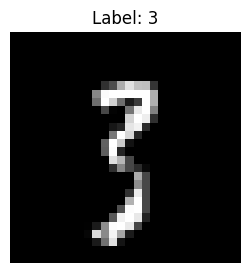

In [21]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor(),                     # из [0,255] в [0,1]
    transforms.Normalize((0.1307,), (0.3081,)) # нормализация (mean=0.1307,std=0.3081)
])


train_data = MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = MNIST(root='./data', train=False, download=True, transform=transform)


train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size

train_data, val_data = random_split(train_data, [train_size, val_size])


train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=True)


images, labels = next(iter(train_loader))


# Печатаем формы тензоров
print("images.shape:", images.shape)   # torch.Size([64, 1, 28, 28])
print("labels.shape:", labels.shape)   # torch.Size([64])


# Выведем метку первого изображения
first_label = labels[0].item()
print("Метка первого изображения в батче:", first_label)


# Отобразим само первое изображение
plt.figure(figsize=(3,3))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {first_label}")
plt.axis('off')
plt.show()